# CineIQ — Exploratory Data Analysis

This notebook explores the MovieLens 1M dataset before building recommendation models.
We analyze rating distributions, genre frequencies, and user behavior patterns.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
movies = pd.read_csv('../data/raw/ml-1m/movies.dat', 
    sep='::', engine='python', 
    names=['movieId', 'title', 'genres'],
    encoding='latin-1')

ratings = pd.read_csv('../data/raw/ml-1m/ratings.dat',
    sep='::', engine='python',
    names=['userId', 'movieId', 'rating', 'timestamp'],
    encoding='latin-1')

In [2]:
# Basic checks
print(movies.shape)
print(ratings.shape)
print(movies.head())
print(ratings.head())

(3883, 3)
(1000209, 4)
   movieId                               title                        genres
0        1                    Toy Story (1995)   Animation|Children's|Comedy
1        2                      Jumanji (1995)  Adventure|Children's|Fantasy
2        3             Grumpier Old Men (1995)                Comedy|Romance
3        4            Waiting to Exhale (1995)                  Comedy|Drama
4        5  Father of the Bride Part II (1995)                        Comedy
   userId  movieId  rating  timestamp
0       1     1193       5  978300760
1       1      661       3  978302109
2       1      914       3  978301968
3       1     3408       4  978300275
4       1     2355       5  978824291


In [3]:
# Merge
df = ratings.merge(movies, on='movieId')
print(df.head())
print(df.shape)

# Save processed
df.to_csv('../data/processed/merged.csv', index=False)
movies.to_csv('../data/processed/movies.csv', index=False)
print("Saved.")

   userId  movieId  rating  timestamp                                   title  \
0       1     1193       5  978300760  One Flew Over the Cuckoo's Nest (1975)   
1       1      661       3  978302109        James and the Giant Peach (1996)   
2       1      914       3  978301968                     My Fair Lady (1964)   
3       1     3408       4  978300275                  Erin Brockovich (2000)   
4       1     2355       5  978824291                    Bug's Life, A (1998)   

                         genres  
0                         Drama  
1  Animation|Children's|Musical  
2               Musical|Romance  
3                         Drama  
4   Animation|Children's|Comedy  
(1000209, 6)
Saved.


## Merging Ratings with Movie Metadata

We merge the ratings with movie titles and genres to create a unified dataset for analysis.

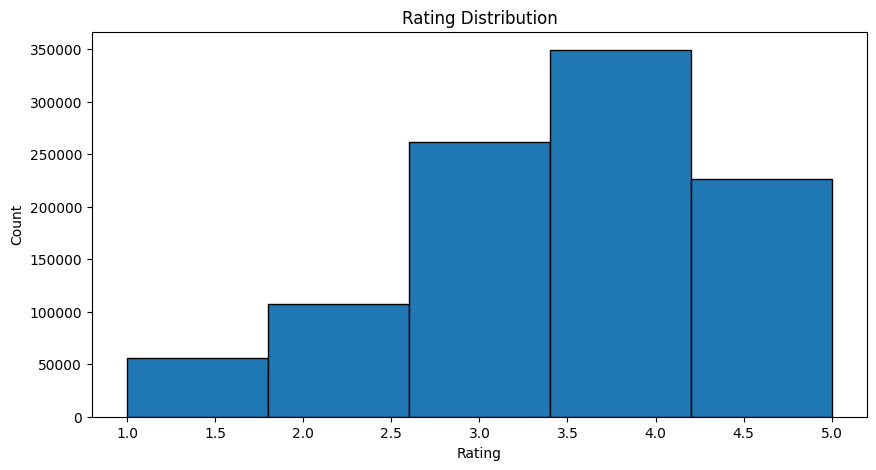

Mean rating: 3.582
Median rating: 4.000
Std dev: 1.117


In [4]:
# Rating distribution
plt.figure(figsize=(10, 5))
df['rating'].hist(bins=5, edgecolor='black', grid=False)
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

print(f"Mean rating: {df['rating'].mean():.3f}")
print(f"Median rating: {df['rating'].median():.3f}")
print(f"Std dev: {df['rating'].std():.3f}")

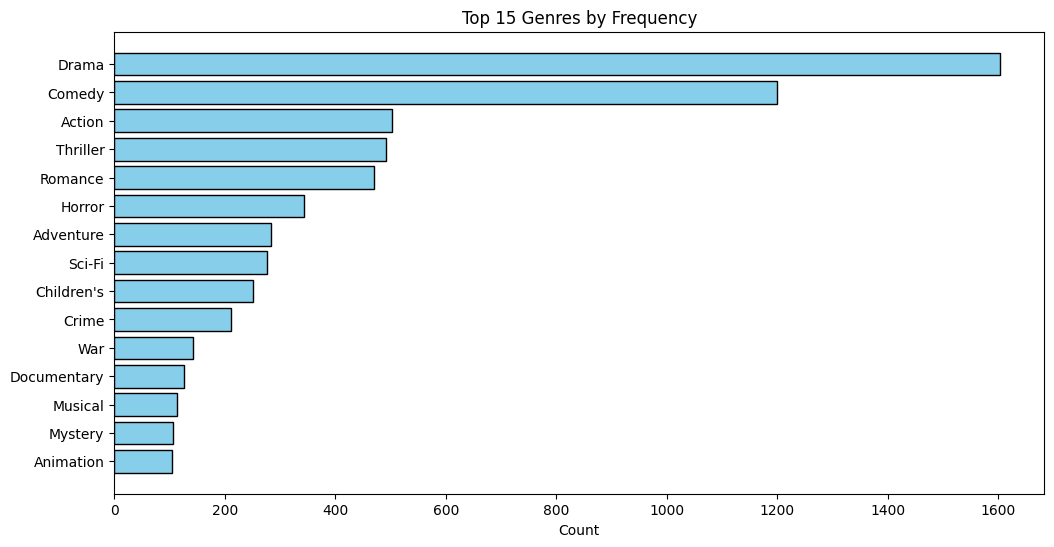

      Genre  Count
      Drama   1603
     Comedy   1200
     Action    503
   Thriller    492
    Romance    471
     Horror    343
  Adventure    283
     Sci-Fi    276
 Children's    251
      Crime    211
        War    143
Documentary    127
    Musical    114
    Mystery    106
  Animation    105


In [5]:
# Genre frequency analysis
from collections import Counter

all_genres = []
for g in movies['genres']:
    all_genres.extend(g.split('|'))

genre_counts = Counter(all_genres)
genre_df = pd.DataFrame(genre_counts.most_common(15), columns=['Genre', 'Count'])

plt.figure(figsize=(12, 6))
plt.barh(genre_df['Genre'], genre_df['Count'], color='skyblue', edgecolor='black')
plt.xlabel('Count')
plt.title('Top 15 Genres by Frequency')
plt.gca().invert_yaxis()
plt.show()
print(genre_df.to_string(index=False))

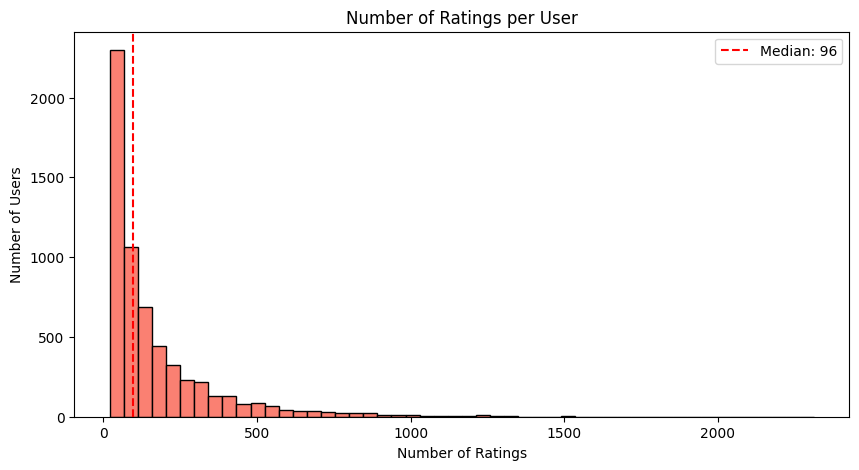

Users: 6040
Avg ratings/user: 165.6
Min: 20, Max: 2314


In [6]:
# User rating behavior
user_counts = df.groupby('userId')['rating'].count()

plt.figure(figsize=(10, 5))
plt.hist(user_counts, bins=50, edgecolor='black', color='salmon')
plt.title('Number of Ratings per User')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')
plt.axvline(user_counts.median(), color='red', linestyle='--', label=f"Median: {user_counts.median():.0f}")
plt.legend()
plt.show()

print(f"Users: {len(user_counts)}")
print(f"Avg ratings/user: {user_counts.mean():.1f}")
print(f"Min: {user_counts.min()}, Max: {user_counts.max()}")

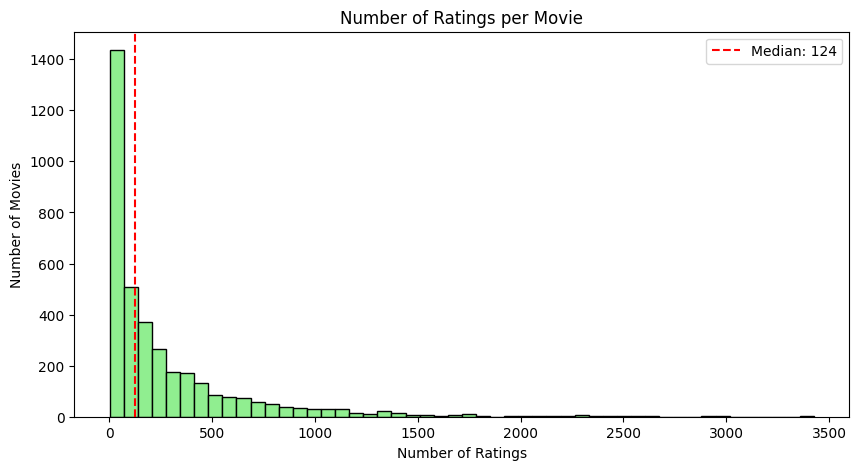

Movies: 3706
Avg ratings/movie: 269.9
Min: 1, Max: 3428


In [7]:
# Movie rating count distribution
movie_counts = df.groupby('movieId')['rating'].count()

plt.figure(figsize=(10, 5))
plt.hist(movie_counts, bins=50, edgecolor='black', color='lightgreen')
plt.title('Number of Ratings per Movie')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Movies')
plt.axvline(movie_counts.median(), color='red', linestyle='--', label=f"Median: {movie_counts.median():.0f}")
plt.legend()
plt.show()

print(f"Movies: {len(movie_counts)}")
print(f"Avg ratings/movie: {movie_counts.mean():.1f}")
print(f"Min: {movie_counts.min()}, Max: {movie_counts.max()}")

## Key Insights
- **Rating distribution** is left-skewed — users tend to rate movies they like (mean ~3.6/5).
- **Drama, Comedy, and Action** dominate the genre landscape.
- **User activity** is highly skewed — power users rate hundreds of movies while many rate fewer than 50.
- **Movie popularity** follows a long-tail distribution — a small fraction of movies receive most ratings.

These insights inform our recommendation strategy: collaborative filtering (SVD) captures the user-rating matrix, content-based filtering leverages genre features, and popularity acts as a fallback for cold-start scenarios.